# Notebook B (esquema CV-animal) — Predicción conforme a nivel de animal
### Tuberculosis bovina · con la explotación incluida como covariable

A diferencia del esquema *leave-one-farm-out*, aquí el muestreo conforme se realiza **a nivel
de animal** sobre el conjunto agrupado. Bajo este diseño, el supuesto de **intercambiabilidad**
es más defendible (particiones aleatorias de animales), por lo que la **garantía de cobertura
marginal** de la predicción conforme aplica de forma estándar. Incluimos la **explotación**
entre las covariables y evaluamos si ello produce conjuntos/intervalos más informativos.

> **Matiz importante:** la validez marginal aquí presupone que los animales son intercambiables
> dentro del conjunto, lo cual es razonable para predecir *dentro de las granjas conocidas*,
> pero **no** habilita extrapolar a granjas nuevas (un modelo con indicadores de granja no
> aplica a explotaciones no vistas). *(Refs.: Molnar 2023; Angelopoulos, Barber & Bates 2026.)*


## 1. Setup

In [1]:
# !pip install -q mapie scikit-learn xgboost matplotlib
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tb_utils as tb
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from mapie.classification import CrossConformalClassifier
from mapie.regression import CrossConformalRegressor
PALETTE=tb.set_plot_style(); tb.set_seeds(tb.SEED)

import os
DATA = next((p for p in ["BD.csv","/mnt/project/BD.csv","data/BD.csv"] if os.path.exists(p)), "BD.csv")
df = tb.clean(tb.load_raw(DATA))
BIOM = tb.MODEL_FEATURES; BIOM_FARM = tb.MODEL_FEATURES + ["Expl"]; NUM = tb.NUM_FEATURES
def pipe_clf(features, cats):
    num=[f for f in NUM if f in features]
    return Pipeline([("prep", tb.make_preprocessor(numeric=num, categorical=cats)),
                     ("clf", LogisticRegression(C=0.3, class_weight="balanced", solver="liblinear",
                              max_iter=4000, random_state=tb.SEED))])
print("Datos:", df.shape)

Datos: (106, 19)


## 2. Conjuntos conformes para Lesiones_TB: ¿añade la granja eficiencia?

Comparamos los conjuntos LAC (CV-conformal, 5 folds) con y sin la explotación entre las
covariables. Una menor "fracción de ambas clases" indica conjuntos más informativos.


In [2]:
d = tb.target_subset(df, "Lesiones_TB"); y = d["Lesiones_TB"].astype(int).values
levels=[0.7,0.8,0.9]
def conformal_sets(features, cats):
    cc=CrossConformalClassifier(estimator=pipe_clf(features,cats), confidence_level=levels,
        conformity_score="lac", cv=StratifiedKFold(5,shuffle=True,random_state=tb.SEED), random_state=tb.SEED)
    cc.fit_conformalize(d[features], y); _,ys=cc.predict_set(d[features]); ys=np.asarray(ys)
    out=[]
    for li,lv in enumerate(levels):
        s=ys[:,:,li]; out.append(dict(nivel=lv, cobertura=s[np.arange(len(y)),y].mean(),
                                       tam_medio=s.sum(1).mean(), pct_ambas=np.mean(s.sum(1)==2)))
    return pd.DataFrame(out), ys

tab_bio,_ = conformal_sets(BIOM, ["RAZA2"])
tab_farm, ys_farm = conformal_sets(BIOM_FARM, ["RAZA2","Expl"])
print("Sin granja (solo biomarcadores):"); print(tab_bio.round(3).to_string(index=False))
print("\nCon granja (biomarcadores + explotación):"); print(tab_farm.round(3).to_string(index=False))
print("\n→ La granja reduce ligeramente el tamaño de conjunto (más eficiente), pero la mayoría")
print("  de los casos sigue incluyendo ambas clases: la incertidumbre individual persiste.")

Sin granja (solo biomarcadores):
 nivel  cobertura  tam_medio  pct_ambas
   0.7      0.849      1.557      0.557
   0.8      0.915      1.726      0.726
   0.9      0.972      1.915      0.915

Con granja (biomarcadores + explotación):
 nivel  cobertura  tam_medio  pct_ambas
   0.7      0.858      1.387      0.387
   0.8      0.887      1.481      0.481
   0.9      0.991      1.858      0.858

→ La granja reduce ligeramente el tamaño de conjunto (más eficiente), pero la mayoría
  de los casos sigue incluyendo ambas clases: la incertidumbre individual persiste.


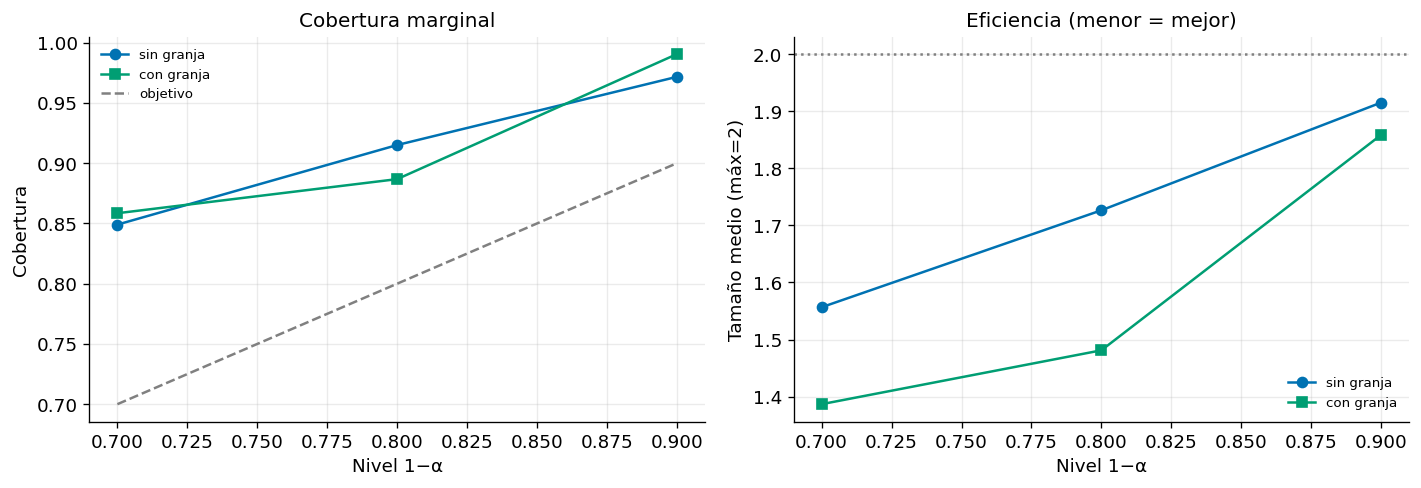

In [3]:
fig, ax = plt.subplots(1,2, figsize=(12,4.2))
ax[0].plot(tab_bio.nivel, tab_bio.cobertura, "o-", color=PALETTE[0], label="sin granja")
ax[0].plot(tab_farm.nivel, tab_farm.cobertura, "s-", color=PALETTE[2], label="con granja")
ax[0].plot(levels, levels, "--", color="grey", label="objetivo")
ax[0].set_xlabel("Nivel 1−α"); ax[0].set_ylabel("Cobertura"); ax[0].set_title("Cobertura marginal"); ax[0].legend(fontsize=8)
ax[1].plot(tab_bio.nivel, tab_bio.tam_medio, "o-", color=PALETTE[0], label="sin granja")
ax[1].plot(tab_farm.nivel, tab_farm.tam_medio, "s-", color=PALETTE[2], label="con granja")
ax[1].axhline(2, ls=":", color="grey"); ax[1].set_xlabel("Nivel 1−α"); ax[1].set_ylabel("Tamaño medio (máx=2)")
ax[1].set_title("Eficiencia (menor = mejor)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/figB1_conformal_efficiency.png"); plt.show()

## 3. Cobertura condicional por explotación

Con la granja en el modelo y muestreo a nivel animal, la cobertura condicional por granja
debería acercarse al objetivo (a diferencia del esquema LOFO, donde la no-intercambiabilidad
entre granjas la desviaba).


Cobertura condicional por granja (objetivo 0.80):
Explotacion  n  cobertura  tam_medio
      VA32D 21      0.905      1.571
      VC30D 55      0.873      1.564
      VC94C 16      1.000      1.250
      WZ72B 14      0.786      1.286


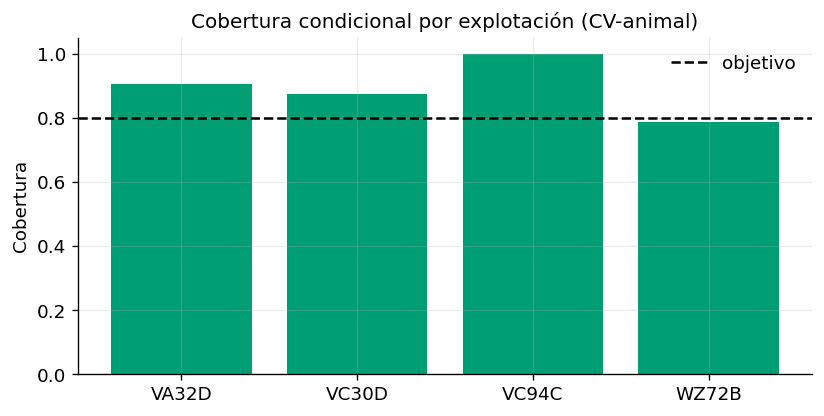

In [4]:
cc=CrossConformalClassifier(estimator=pipe_clf(BIOM_FARM,["RAZA2","Expl"]), confidence_level=0.8,
    conformity_score="lac", cv=StratifiedKFold(5,shuffle=True,random_state=tb.SEED), random_state=tb.SEED)
cc.fit_conformalize(d[BIOM_FARM], y); _,s80=cc.predict_set(d[BIOM_FARM]); s80=np.asarray(s80)[:,:,0]
cov=s80[np.arange(len(y)),y]; size=s80.sum(1)
rows=[]
for lvl,grp in d.groupby("Expl"):
    m=d.index.get_indexer(grp.index)
    rows.append(dict(Explotacion=lvl, n=len(grp), cobertura=cov[m].mean(), tam_medio=size[m].mean()))
cc_tab=pd.DataFrame(rows); print("Cobertura condicional por granja (objetivo 0.80):")
print(cc_tab.round(3).to_string(index=False))
fig,ax=plt.subplots(figsize=(7,3.6))
ax.bar(cc_tab.Explotacion, cc_tab.cobertura, color=PALETTE[2]); ax.axhline(0.8, ls="--", color="k", label="objetivo")
ax.set_ylabel("Cobertura"); ax.set_title("Cobertura condicional por explotación (CV-animal)"); ax.legend()
plt.tight_layout(); plt.savefig("figures/figB2_conditional_coverage.png"); plt.show()

## 4. Intervalos conformes para IDTC (con granja)

In [5]:
def reg_pipe(features, cats):
    num=[f for f in NUM if f in features]
    return Pipeline([("prep", tb.make_preprocessor(numeric=num, categorical=cats)),
                     ("clf", xgb.XGBRegressor(n_estimators=150,max_depth=2,learning_rate=0.05,
                              subsample=0.8,reg_lambda=3.0,random_state=tb.SEED))])
yreg=df["IDTC"].values.astype(float)
rows=[]
for label,(feats,cats) in {"sin granja":(BIOM,["RAZA2"]),"con granja":(BIOM_FARM,["RAZA2","Expl"])}.items():
    for lvl in [0.7,0.8,0.9]:
        cr=CrossConformalRegressor(estimator=reg_pipe(feats,cats), confidence_level=lvl, cv=5)
        cr.fit_conformalize(df[feats], yreg); _,yi=cr.predict_interval(df[feats]); yi=np.asarray(yi)[:,:,0]
        rows.append(dict(modelo=label, nivel=lvl, cobertura=((yreg>=yi[:,0])&(yreg<=yi[:,1])).mean(),
                         ancho=(yi[:,1]-yi[:,0]).mean()))
print("IDTC — intervalos conformes (rango observado = 32):")
print(pd.DataFrame(rows).round(2).to_string(index=False))
print("→ Incluir la granja estrecha algo los intervalos, pero siguen siendo anchos.")

IDTC — intervalos conformes (rango observado = 32):
    modelo  nivel  cobertura  ancho
sin granja    0.7       0.90  13.95
sin granja    0.8       0.97  17.97
sin granja    0.9       0.99  24.95
con granja    0.7       0.89  13.79
con granja    0.8       0.95  17.55
con granja    0.9       1.00  23.70
→ Incluir la granja estrecha algo los intervalos, pero siguen siendo anchos.


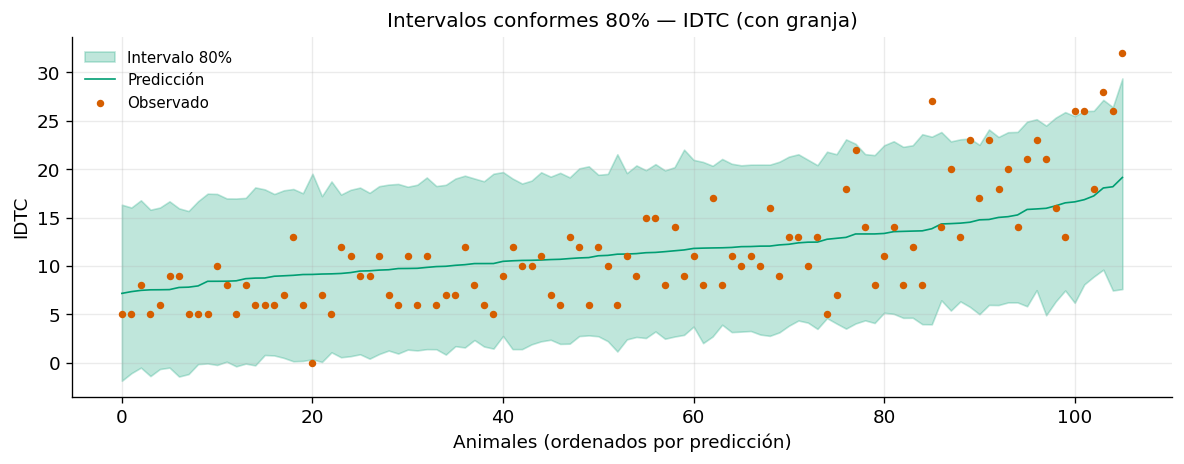

In [6]:
# Visual: intervalos 80% con granja, ordenados por predicción
cr=CrossConformalRegressor(estimator=reg_pipe(BIOM_FARM,["RAZA2","Expl"]), confidence_level=0.8, cv=5)
cr.fit_conformalize(df[BIOM_FARM], yreg); yp,yi=cr.predict_interval(df[BIOM_FARM])
yp=np.asarray(yp).ravel(); yi=np.asarray(yi)[:,:,0]; o=np.argsort(yp)
fig,ax=plt.subplots(figsize=(10,4))
ax.fill_between(range(len(o)), yi[o,0], yi[o,1], alpha=.25, color=PALETTE[2], label="Intervalo 80%")
ax.plot(range(len(o)), yp[o], color=PALETTE[2], lw=1, label="Predicción")
ax.scatter(range(len(o)), yreg[o], s=12, color=PALETTE[1], label="Observado", zorder=3)
ax.set_xlabel("Animales (ordenados por predicción)"); ax.set_ylabel("IDTC")
ax.set_title("Intervalos conformes 80% — IDTC (con granja)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig("figures/figB3_conformal_intervals.png"); plt.show()

## 5. Conclusiones del esquema conforme CV-animal

- La predicción conforme a nivel animal tiene **validez marginal** bien fundamentada
  (intercambiabilidad razonable dentro del conjunto).
- Incluir la **explotación** mejora **marginalmente** la eficiencia (conjuntos algo menores,
  intervalos algo más estrechos) y **equilibra** la cobertura condicional por granja respecto
  al esquema LOFO.
- Aun así, la incertidumbre individual sigue siendo **alta** (mayoría de conjuntos con ambas
  clases; intervalos anchos): los biomarcadores no permiten un triaje individual fiable, ni
  siquiera condicionando en la granja.
